<a href="https://colab.research.google.com/github/NanoBurgos/Penguin_Academy/blob/main/challenges/desafio5_conexion0/Sockets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Sockets con Python - Introducción**

https://www.youtube.com/watch?v=8gm1GcJR7R8



protocolos de comunicacion
TCP / IP


La comunicación TCP/IP es el conjunto de reglas (protocolos) que permiten que las computadoras se comuniquen entre sí a través de redes como Internet.

#**¿Qué significa TCP/IP?**

TCP → Transmission Control Protocol (Protocolo de Control de Transmisión)

IP → Internet Protocol (Protocolo de Internet)

Juntos forman la base de toda comunicación en Internet.

#**¿Qué hace cada uno?**
**IP (Internet Protocol)**

Se encarga de direccionar los datos.

Divide la información en paquetes y los envía a través de la red.

Cada dispositivo tiene una dirección IP (como una dirección postal) para poder ser identificado.

👉 Ejemplo:
Cuando envías un mensaje, el protocolo IP se encarga de llevarlo a la dirección correcta (como un cartero llevando cartas).

.......

**TCP (Transmission Control Protocol)**

Garantiza que los paquetes lleguen completos y en orden.

Si alguno se pierde, lo vuelve a pedir.

Asegura una comunicación confiable entre emisor y receptor.

👉 Ejemplo:
Si envías un archivo de 100 partes y solo llegan 98, TCP detecta cuáles faltan y las solicita de nuevo.


#**¿Cómo funciona juntos?**

    1 Tu computadora divide los datos en paquetes (TCP).

    2 Les asigna una dirección de destino (IP).

    3 Los paquetes viajan por la red (IP).

    4 El receptor los reordena y verifica (TCP).

    5 Se reconstruye el mensaje original.

**Ejemplo práctico**

    Cuando abres una página web:

    1 Tu navegador usa TCP/IP para conectarse al servidor del sitio.

    2 El servidor envía los datos de la página en paquetes TCP/IP.

    3 Tu navegador los recibe, los ordena y muestra la página correctamente.

En resumen

    Protocolo: IP
    Función principal: Envía paquetes al destino correcto
    Tipo: No confiable (solo entrega)
    
    Protocolo: TCP
    Función principal: Asegura que los paquetes lleguen completos y en orden
    Tipo:	Confiable (control de errores)


#**PUERTOS TCP - UDP**

#**Metodos que vamos a utilizar para construir nuestro programa**

- socket()
- bind()
- listen()
- accept()
- connect_ex()
- send()
- recv()
- close()

un socket se crea un objeto socket, es decir se instancia un objeto clase socket

socket.socket()

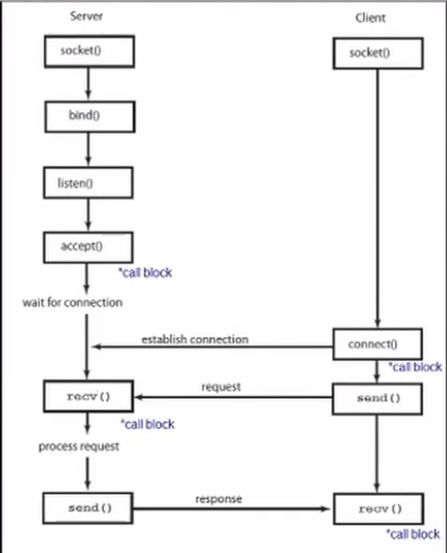

un socket es una combinacion de direccion de red y puerto, basicamente establece una puerta de entrada y salida

**bind()** - asocia este socket con un recurso fisico con una tarjeta de red, ya sea para comunicacion por cable, inalambrica, por lo general se usa la tarjeta ethernet del equipo

**listen()** - coloca todo lo construido en modo de escucha, de modo a que el servidor este escuchando conexiones entrantes

**accept()** - pone esto en un modo blocking, blocinkg quiere decir que el sistema se queda esperando a que algo suceda

**Como se distinguen los nodos?**
el cliente se conecta con un solo servidor - (uno a uno)
pero el servidor puede estar conectado con varios clientes - (uno a muchos)

#**Sockets con Python - Hola Mundo**

https://www.youtube.com/watch?v=AU7nNGTqKT0

El servidor y el cliente deben estar en archivos/modulos por separados,

#***Crearemos los archivos/modulos para el servidor y para el cliente***

#**Archivo - SERVER**

In [ ]:
import socket

"""El cliente y el servidor van a estar en el mismo equipo, van a tener la misma direccion IP, pero vamos a distinguirlos en algunas cosas"""

HOST = "127.0.0.1" #Direccion loopback (direccion del propio equipo)

PORT = 65123 #ES UN PUERTO ALTO (PUERTO DE ESCUCHA) (todos los puertos mayores a 1023 estan liberados)


# with socket.socket(IP, TCP)
"""
socket.AF_INET con esto estamos especificando que estamos utilizando el protocolo IP de red version IPV4
AF significa adress family(familia de direcciones IP)
"""

with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s: #nuestro socket se va a llamar "s"
    s.bind((HOST, PORT)) #Ya tenemos un recurso fisico asociado a ese socket

    s.listen() #ponemos el socket en modo escucha

    conn, addr = s.accept() #metodo tipo blocking(se queda esperando) para aceptar conexiones entrantes

    #conn guarda el socket del cliente , addr guarda la direccion del cliente

    with conn:
        print(f"Conectado a {addr}: ") #vamos a mostrar la conexion IP del cliente
        while True:
            data = conn.recv(1024) #valor estandar para recibir 1k de datos
            if not data:
                break
            conn.sendall(data)



#**Archivo - CLIENTE**

In [ ]:
import socket

HOST = "120.0.0.1" #USAMOS EL MISMO QUE EL DEL SERVIDOR, por que estamos en el mismo equipo

PORT = 65123 #TAMBIEN DEBE SER EL MISMO (Pero en este caso es el puerto de envio, el del servidor es de escucha)

with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
    s.connect((HOST, PORT))

    s.sendall(b"Hola mundo") #la b al inicio es para indicar que es un string binario

    data = s.recv(1024) #recibir es una funcion tipo blocking

    #cuando reciba los datos saldremos del bloque with

print("Recibido", repr(data))


#**Que es una conexion ip?**
Una conexión IP es la comunicación entre dos dispositivos (como computadoras, celulares o servidores) que usan el Protocolo de Internet (IP) para enviar y recibir datos a través de una red, como Internet o una red local.

🌐 **En palabras simples:**

Cuando te conectás a Internet, tu dispositivo obtiene una dirección IP, que es como su número de identificación o dirección postal digital.
Gracias a esa dirección, otros dispositivos pueden encontrarte y enviarte información correctamente.

⚙️ **Cómo funciona:**

Tu dispositivo obtiene una IP (por ejemplo, 192.168.1.10 o 200.55.88.12).

Cuando enviás datos (por ejemplo, al abrir una página web), esos datos se dividen en paquetes.

Cada paquete lleva la IP de origen (la tuya) y la IP de destino (el servidor).

La red los envía al destino correcto.

El receptor puede responder usando tu IP, completando la conexión.

📫 **Ejemplo:**

Tu computadora (IP: 192.168.1.5) quiere acceder a Google (IP: 142.250.190.78).

Se crea una conexión IP entre ambas.

Los paquetes de datos viajan de un lado al otro identificados por esas IPs.

#**PAGINA - Programación de sockets en Python (Guía)**

https://realpython.com/python-sockets/